# MSIN0097 Predictive Analytics Individual Assignment - Customer Churn Prediction 
# Candidate Number: RRMZ8

## Task 1. Obtain a dataset and frame the predictive problem

This project uses the **Customer Churn Dataset**
([Kaggle source, CC0 licence](https://www.kaggle.com/datasets/anandshaw2001/customer-churn-dataset/data)),
distributed as a CSV file (`customer_churn.csv`). The dataset contains **10,000** records and **14** features of retail-banking customers across
three European markets (France, Germany, Spain).
Each row represents **one customer at a single point in time** and includes
demographic attributes (`Age`, `Gender`, `Geography`), account-level features
(`Credit score`, `Balance`, `Number of products`, `Tenure`), and behavioural
indicators (`Is Active Member`, `Has Credit Ccard`).
There are three identifier columns (`RowNumber`, `CustomerId`, `Surname`). They will will be dropped before modelling as they carry no predictive signal.

- Data access:
  A **200-row stratified sample** is included in the repository at
`data/sample_customer_churn.csv` so that all scripts can run out of the box
for a quick preview.
  The **full dataset** is not committed; to reproduce the final
results, download the CSV from the
[Kaggle page](https://www.kaggle.com/datasets/anandshaw2001/customer-churn-dataset/data)
and place it at exactly `data/customer_churn.csv`.


 

In [69]:
#Import packages
import numpy as np
import pandas as pd

from pandas import Series, DataFrame

In [70]:
#Importing the dataset
df = pd.read_csv("data/Churn_Modelling.csv")
df.head()  #checking for the first 5 rows

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [71]:
# Quick sanity check: how many rows and columns did we load into df
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")

Loaded 10000 rows, 14 columns




### 1.1  Target and Prediction Type



In [72]:
# The target is "Exited"
# Count how many rows belong to each class of the target column "Exited"
# 0 -> number of retained customers, 1 -> number of churned customers
counts = df["Exited"].value_counts()

# Compute the churn rate as a percentage
# Because Exited is 0/1, we can use mean() to figure out the rate
churn_rate = df["Exited"].mean() * 100

# Retained rate is the remaining percentage (proportion of 0s)
retained_rate = 100 - churn_rate

# Print the raw counts and the percentages
print("Counts:\n", counts)
print(f"Churn rate (Exited=1): {churn_rate:.2f}%")
print(f"Retained rate (Exited=0): {retained_rate:.2f}%")

Counts:
 Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate (Exited=1): 20.37%
Retained rate (Exited=0): 79.63%


| Item | Value |
|------|-------|
| Target column | `Exited` |
| Prediction type | Binary classification |
| Positive class (`Exited = 1`) | Customer **did churn** — they closed their account or left the bank |
| Negative class (`Exited = 0`) | Customer **retained** — they remained an active customer |
| Class balance | **20.37%** positive / **79.63%** negative — the dataset is imbalanced toward the majority (retained) class |



The business goal is to **predict which customers are most likely to churn**
so that the bank can intervene with targeted retention offers before
the customer leaves.



### 1.2  Success Metrics and Constraints

### Metrics

| Role | Metric | Why |
|------|--------|-----|
| **Primary** | **PR-AUC** (area under the Precision–Recall curve) | With an imbalanced dataset, PR-AUC gives a more informative summary of performance across thresholds than ROC-AUC, because it is sensitive to false-positive inflation in the minority class (Davis & Goadrich, 2006). |
| **Secondary** | **ROC-AUC** | A widely reported threshold-free metric that allows comparison with published benchmarks. Less sensitive to class imbalance than PR-AUC but still useful as a complementary view. |
| **Operational** | **Recall @ top 20%** | Simulates a realistic business constraint: if the retention team can contact only the top 20% of customers ranked by predicted churn probability, what fraction of actual churners does the model capture? This directly measures the model's usefulness under limited intervention capacity. |
| **Operational** | **Precision @ top 20%** | Of the 20% of customers the model flags as highest-risk, what fraction are genuine churners? This measures campaign cost-efficiency — high precision means fewer wasted retention offers sent to loyal customers. Together with Recall@top-20%, it fully characterises the quality of the top-20% operating bucket. |

### Constraints

1. **Interpretability.** Stakeholders need to understand *why* a customer is flagged. At minimum, feature-importance rankings and, ideally, per-prediction explanations should be available.
2. **Fairness.** The model should not systematically under-serve customers by `Geography` or `Gender`. Disparate false-negative rates across protected groups would mean some segments receive fewer retention offers.
3. **Cost asymmetry of errors.** A false negative (missing a churner) is more costly than a false positive (offering retention to a loyal customer). Metric choice and threshold selection should reflect this asymmetry.
4. **Runtime.** Training and inference must complete within minutes on a standard laptop, ruling out approaches that require GPU infrastructure.
5. **Reproducibility.** Fixed random seeds, pinned dependencies (`requirements.txt`), and a single entry-point script/notebook  must allow anyone to reproduce results end-to-end.



### 1.3  Assumptions and Limitations

1. **Cross-sectional snapshot.** The dataset captures customers at a single point in time. We assume this snapshot is representative of the population the model would score in production, but we cannot model temporal dynamics (e.g., trends in churn rate over time).
2. **No temporal leakage check possible.** Without a date column, we cannot verify that features were recorded *before* the churn event. We proceed on the assumption that all features are legitimately available at prediction time.
3. **Stationarity.** We assume the relationship between features and churn is stable. In practice, economic conditions, product changes, or competitor actions could cause distribution shift.
4. **Feature completeness.** The dataset contains only **14** features. Important predictors available to a real bank — transaction frequency, customer-service call logs, recent product changes — are absent, likely limiting model performance.
5. **Geographic scope.** Only three countries (France, Germany, Spain) are represented. Results may not generalise to other markets.
6. **Label reliability.** We treat `Exited` as ground truth. We assume it was recorded accurately and that the definition of "churn" is consistent across all rows.
7. **No cost matrix available.** We discuss cost asymmetry qualitatively (Section 1.2) but do not have actual monetary values for false positives vs. false negatives, so threshold optimisation is illustrative rather than business-calibrated.
8. **Sample size.** At **10,000** rows and a **20.37%** churn rate, the minority class contains approximately **2037** examples. This is adequate for the models considered but limits the precision of metrics estimated on validation and test splits.

### 1.4 Agent tooling expectation: my plan, what I asked the agent to do, and what I verified myself

I used the agent for speed on boilerplate and first drafts, but I kept all correctness critical decisions under my control. My workflow plan was:

**What I asked the agent to do**

* **Project scaffolding:** create a minimal repo structure with README, `.gitignore`, and `requirements.txt`, plus a sensible folder layout for a notebook first workflow.
* **Data access setup:** draft a `src/data_loader.py` that can load the full dataset locally, fall back to a small committed sample for reproducibility, and raise a clear error if neither exists. Add dataset access instructions to the README.
* **Section 1 draft:** produce a first pass of Section 1.1 to 1.5 in markdown with placeholders for dataset specific numbers, metric definitions, and assumptions, so I could fill them after running the notebook.
* **Metric table:** include a metric shortlist aligned to the operating rule I planned to use later, and format it consistently for reuse in later tasks.

**What I verified or corrected myself (and how)**

* **Repo files are correct and consistent:** I reviewed every generated file and fixed naming consistency (`Churn Modelling` to `Churn_Modelling`). I also enforced coursework specific requirements that the agent did not infer reliably: adding a Dummy baseline and an MLP to the model set requirement, and adding `.xlsx` to `.gitignore`.
* **Data loading is actually runnable:** I executed a sanity check to test three paths in `src/data_loader.py`: full load works when the full CSV exists, sample fallback works when it does not, and the missing file path raises a clear error. I also confirmed the full dataset is not tracked by git while the 200 row sample is committed, so the repo remains reproducible.
* **Section 1 content is evidence based:** I filled all placeholders only after running the notebook and reading the dataset documentation. I validated the metric rationale against lecture notes and checked assumptions against what the dataset actually contains rather than leaving them as generic text.
* **Metric choice is aligned and consistent end to end:** I explicitly requested adding Precision at top 20 percent as a fourth metric alongside Recall at top 20 percent. I then verified that the wording and definitions match what is later implemented in Tasks 4 and 5, so the report and the notebook evaluate the same business decision rule.

 

## Task 2. Explore the data to gain insights

In [73]:
#Import Packages
# Help create a new folder to save plots 
import os
os.makedirs("outputs", exist_ok=True)
# Packages for help producing plots
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [74]:
#Summary Stats sets context for numeric features
df.describe(include = "all")

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


Summary statistics suggest distinct customer engagement segments. From continuous numerical features, many customers have a zero `Balance`, while the rest span a wide `Balance` range. `Age` also varies widely, so churn risk may differ across life stages. Most customers hold one to two products, with only a small minority holding three to four. From categorical features, `Geography` is dominated by France, and `Gender` is close to balanced. About half of the customers are active members, so activity status is a strong behavioural feature to test in the churn model.

### 2.1 Target class balance

Plot 1 shows the dataset is **moderately imbalanced**: about 79.6 percent retained (Exited equals 0) and 20.4 percent churned (Exited equals 1). This supports using PR AUC and a stratified split rather than accuracy as the main evaluation focus (Section 1(b)).


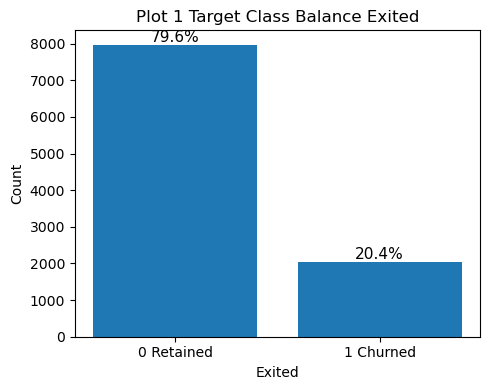

In [75]:
# Define the target column name as a string.
TARGET = "Exited"

# Count how many rows are in each class (0 retained, 1 churned) and sort.
counts = df[TARGET].value_counts().sort_index()

# Compute the percentage of each class.
pcts = df[TARGET].value_counts(normalize=True).sort_index() * 100

# Create a new figure and one axes object for plotting.
fig, ax = plt.subplots(figsize=(5, 4))

# Draw a bar chart with x labels as "0" and "1" and heights as the class counts.
bars = ax.bar(counts.index.astype(str), counts.values)

# Add percentage text labels on top of each bar.
# zip(bars, pcts.values) pairs each bar object with its percentage value.
for bar, pct in zip(bars, pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position: center of the bar
        bar.get_height(),                    # y position: top of the bar
        f"{pct:.1f}%",                       # text to display (1 decimal place)
        ha="center",                         # horizontally centered
        va="bottom",                         # placed just above the bar
        fontsize=11
    )

# Label the axes so the plot is readable.
ax.set_xlabel("Exited")   # x axis represents class label
ax.set_ylabel("Count")    # y axis represents number of customers

# Add a title to describe what the plot shows.
ax.set_title("Plot 1 Target Class Balance Exited")

# Force the x axis to show ticks at 0 and 1 (the two classes).
ax.set_xticks([0, 1])

# Replace the tick labels with human readable meanings.
ax.set_xticklabels(["0 Retained", "1 Churned"])

# Adjust spacing so labels and title do not get cut off.
fig.tight_layout()

# Save the figure.
fig.savefig("outputs/eda_01_target_balance.png", dpi=150)

plt.show()

### 2.2 Missing values

Plot 2 confirms zero missing values across all features, so no imputation is required. This allows us to proceed directly to modelling without introducing any imputation bias. However, we should still be careful, as real-world bank customer datasets often contain missing values and require a missing-value handling step.  

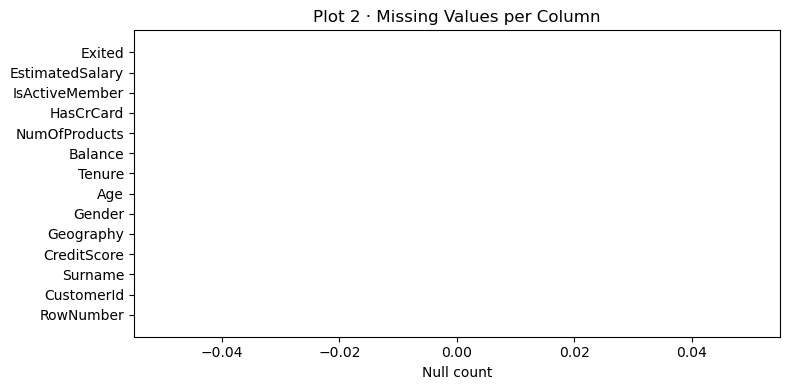

Total missing: 0


In [76]:
# Count missing (null) values in each column.
nulls = df.isnull().sum()

# Create a figure and one axis for the plot.
fig, ax = plt.subplots(figsize=(8, 4))

# Plot a horizontal bar chart:
# y axis shows column names (nulls.index), bar lengths show missing counts (nulls.values).
ax.barh(nulls.index, nulls.values, color="steelblue")

# Label the x axis so it is clear what the bar lengths represent.
ax.set_xlabel("Null count")

# Add a title describing what the plot shows.
ax.set_title("Plot 2 · Missing Values per Column")

# Adjust spacing so labels do not get cut off.
plt.tight_layout()

# Save the plot image into the outputs folder (useful as evidence for the report).
plt.savefig("outputs/eda_02_missingness.png", dpi=150)

# Display the plot in the notebook.
plt.show()

# Print the total number of missing values across the whole dataset
print("Total missing:", nulls.sum())


### 2.3 Numeric Distributions
Below used histograms to describe the distribution of 5 continuous numerical features (e.g., skew, zero inflation, tails). The histogram plots confirm the distribution shapes suggested by the summary statistics.

* `Age` is **right skewed**, with most customers clustered around working age and a smaller tail of older customers.
* `Tenure` is fairly evenly spread across 0 to 10 years, so tenure alone may have limited separation power unless combined with other features.
* `Balance` has a **clear spike at zero** and a long right tail among non zero customers, indicating distinct engagement patterns and a feature that may need careful handling.
* `CreditScore` is roughly bell shaped, suggesting a relatively stable spread of credit quality.
* `EstimatedSalary` appears close to uniform, which may make it a weaker predictor than behavioural indicators.


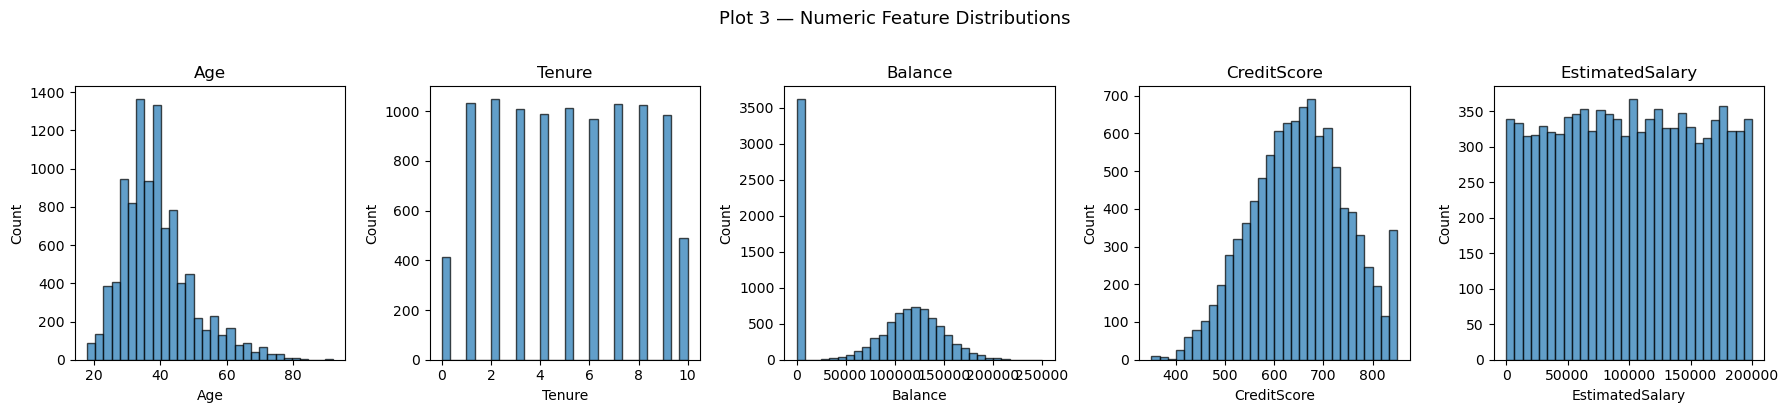

In [77]:
# Categorical features like Geography and Gender have only 2–3 discrete values, 
# so a bar chart of their counts conveys little insight beyond what `value_counts()` already shows.
# Then we choose a list of continous numeric columns to plot as histograms
hist_cols = ["Age", "Tenure", "Balance", "CreditScore", "EstimatedSalary"]

# Create a single figure with 1 row and (number of columns) subplots
# figsize controls the overall width and height of the whole figure (in inches)
fig, axes = plt.subplots(1, len(hist_cols), figsize=(18, 4))

# Loop through each subplot axis and its corresponding column name
for ax, col in zip(axes, hist_cols):
    # Draw a histogram of the column values, bins=30 splits the data into 30 intervals     
    ax.hist(df[col], bins=30, edgecolor="black", alpha=0.7)

    # Add a title above each subplot showing the feature name
    ax.set_title(col)

    # Label the x axis with the feature name
    ax.set_xlabel(col)

    # Label the y axis as count (how many records fall in each bin)
    ax.set_ylabel("Count")

fig.suptitle("Plot 3 — Numeric Feature Distributions", y=1.02, fontsize=13)

fig.tight_layout()

fig.savefig("outputs/eda_03_numeric_distributions.png", dpi=150)

plt.show()

### 2.4 Categorical churn rates

Here, we compare churn rate across several categorical features to gain insights.

- `Geography `: Germany has a much higher churn rate, about 32.4%, compared with France 16.2% and Spain 16.7%.
This is a large gap, so `Geography` looks like a strong categorical signal, especially the Germany group.

- `Gender`: Female churn is higher at about 25.1% versus Male 16.5%.
This suggests `Gender` contains signal, but it may also be picking up other differences in the customer profile, so treat it as an association, not a cause.

- `IsActiveMember`: This is the clearest categorical effect. Inactive customers (0) churn about 26.9%, while active customers (1) churn about 14.3%.
Activity status looks strongly linked to churn and should help the model.

- `HasCrCard`: The churn rates are almost the same, about 20.8% for 0 and 20.2% for 1.
This suggests `HasCrCard` alone adds little signal, although it can still help slightly when combined with other features.

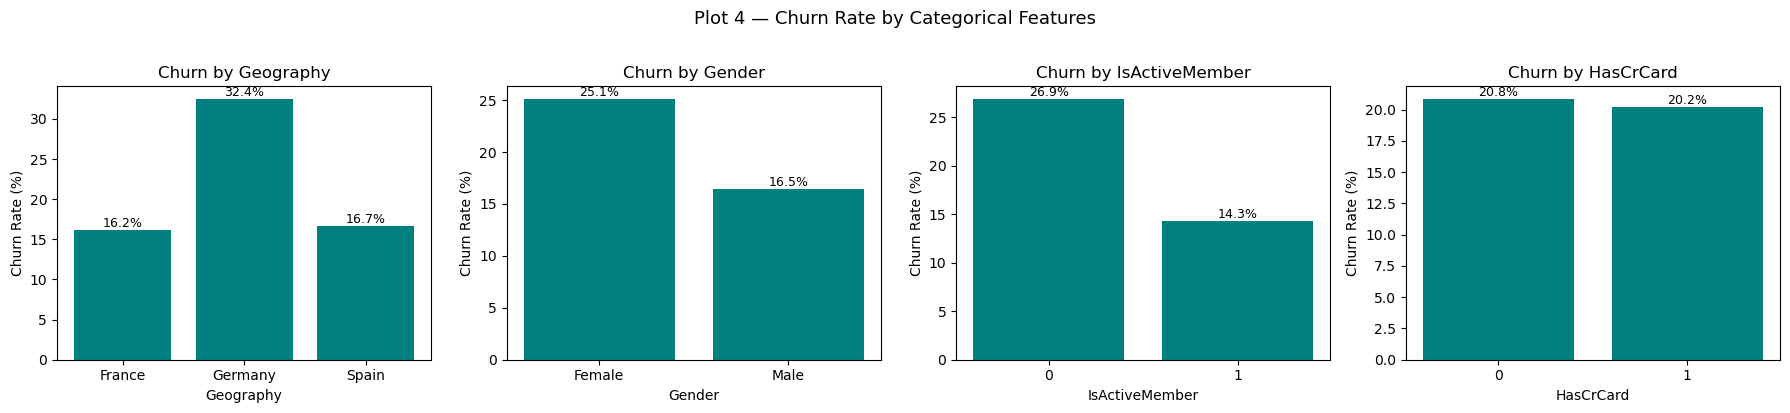

In [78]:
cat_cols = ["Geography", "Gender", "IsActiveMember", "HasCrCard"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))

# Loop through each subplot axis and its corresponding categorical column
for ax, col in zip(axes, cat_cols):

    # Group by the category and compute the mean of TARGET (Exited)
    # Since Exited is 0 or 1, the mean is the churn rate
    rates = df.groupby(col)[TARGET].mean() * 100

    # Draw a bar chart of churn rate for each category level
    bars = ax.bar(rates.index.astype(str), rates.values, color="teal")

    # Add a percentage label above each bar
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,   
            bar.get_height(),                   
            f"{bar.get_height():.1f}%",        
            ha="center", va="bottom",
            fontsize=9
        )

    # Label axes and add a subplot title
    ax.set_xlabel(col)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title(f"Churn by {col}")

fig.suptitle("Plot 4 — Churn Rate by Categorical Features", y=1.02, fontsize=13)

fig.tight_layout()

# Save the figure locally  
fig.savefig("outputs/eda_04_churn_by_category.png", dpi=150)

plt.show()

### 2.5 Boxplots by churn status

`Age` is the clearest numeric difference. The churned group has a noticeably higher median age and a higher central range, which supports the earlier result that churn risk increases with age. And there are some very high age outliers beyond the upper whisker.

`Balance`  has a **big zero balance group** and **very large values** (outliers). It can mislead models unless handled carefully; for example, use a log transform or add a binary indicator.

`CreditScore` and `EstimatedSalary` look very similar for churned and retained customers. This means they do not separate the two groups well on their own. `CreditScore` shows a few low outliers. However, a weak marginal signal does not rule out usefulness inside a multivariate model where interactions with other features may still matter.

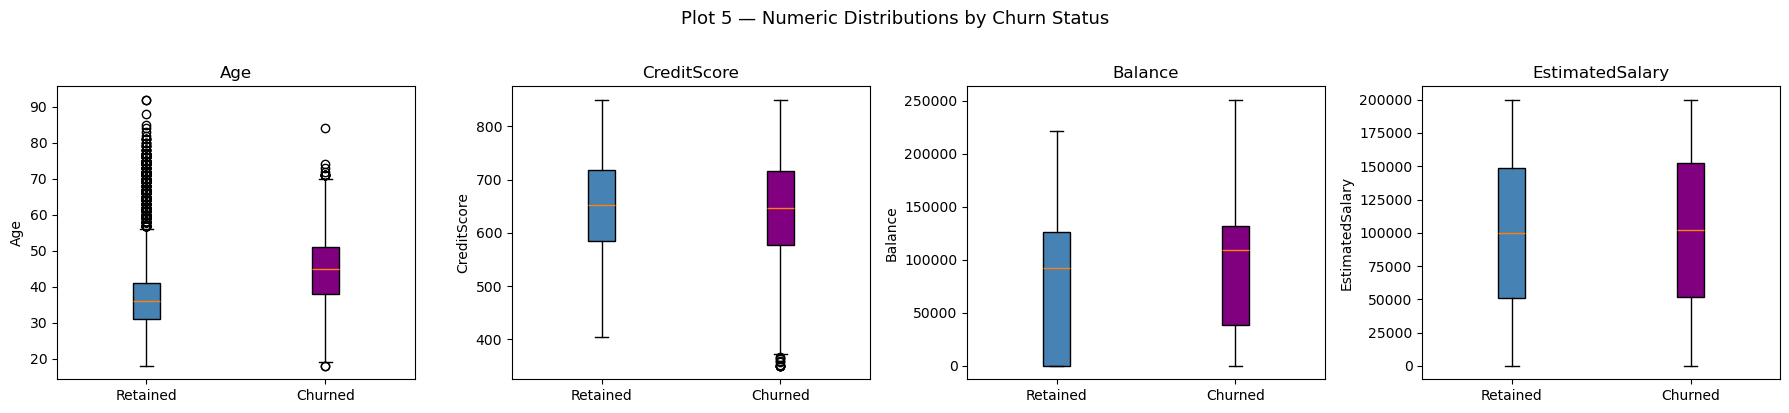

In [79]:
# Choose numeric columns to compare between churned vs retained customers.
# Boxplots help show differences in median, spread, and potential outliers.
box_cols = ["Age", "CreditScore", "Balance", "EstimatedSalary"]

# Create one figure with 1 row of subplots, one subplot per column in box_cols.
# figsize controls the overall size of the figure (width, height) in inches.
fig, axes = plt.subplots(1, len(box_cols), figsize=(18, 4))

# Loop over each subplot axis and its corresponding column name.
for ax, col in zip(axes, box_cols):
    # Split the data into two groups based on the target:
    # Exited = 0 means retained, Exited = 1 means churned.
    data_0 = df.loc[df[TARGET] == 0, col]
    data_1 = df.loc[df[TARGET] == 1, col]

    # Draw a boxplot comparing the two groups side by side.
    # tick_labels names the two boxes so the plot is readable.
    bp = ax.boxplot(
        [data_0, data_1],
        tick_labels=["Retained", "Churned"],
        patch_artist=True
    )

    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("purple")

    # Label the y axis with the feature name, since values differ per subplot.
    ax.set_ylabel(col)

    # Title each subplot with the feature name.
    ax.set_title(col)
 
fig.suptitle("Plot 5 — Numeric Distributions by Churn Status", y=1.02, fontsize=13)

fig.tight_layout()

# Save the figure to the outputs folder.
fig.savefig("outputs/eda_05_boxplots_by_churn.png", dpi=150)

plt.show()

### 2.6 Correlation heatmap (Leakages Risks)

The correlation heatmap shows that most numeric features have weak linear relationships with churn. The clearest signal is `Age`, which has a moderate positive correlation with `Exited` (about 0.29), suggesting churn is more common among older customers in this dataset. `Balance` has a small positive correlation with `Exited` (about 0.12), meaning higher balance is associated with a slightly higher churn tendency, but the effect is weak on its own.

But  `CreditScore`, `Tenure`, `NumOfProducts`, and `EstimatedSalary` are all close to zero, indicating they do not exhibit strong linear churn patterns in isolation.

Between the predictors, the strongest relationship is  `Balance` versus `NumOfProducts` (about - 0.30). This suggests customers with more products tend to have lower balances, or that product holding and balance reflect different usage profiles.
 
Overall, because most correlations are small, much of the predictive signal may come from nonlinear effects and interactions rather than simple straight-line relationships, so we should use models to capture that structure.

For leakage, I ran a screen using a conservative threshold of |r| > 0.8 between each feature and the target. No feature exceeded this threshold, so there is no evidence of correlation-based leakage. However, identifiers like fields (`RowNumber, CustomerId, Surname`) are still removed before modelling because they can encourage memorisation and overfitting rather than generalisable learning.

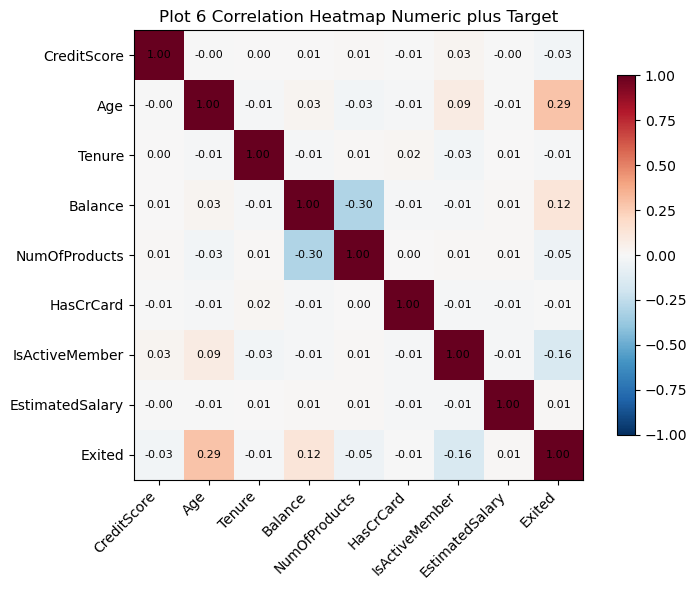

Signed correlation with target (Exited):
Age                0.285
IsActiveMember    -0.156
Balance            0.119
NumOfProducts     -0.048
CreditScore       -0.027
Tenure            -0.014
EstimatedSalary    0.012
HasCrCard         -0.007
Name: Exited, dtype: float64


In [80]:
# Select only the numeric feature columns plus the target column,
# then compute the Pearson correlation matrix (values between -1 and 1).
TARGET = "Exited"
NUMERIC = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"]

corr = df[NUMERIC + [TARGET]].corr()

# Create a figure and axis for the heatmap.
fig, ax = plt.subplots(figsize=(8, 6))

# Display the correlation matrix as an image (heatmap).
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

# Set tick positions on both axes (one tick per column/row in the correlation matrix).
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))

# Label the ticks with the column names.
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Add the correlation value as text inside each heatmap cell.
# corr.iloc[i, j] accesses the correlation at row i, column j.
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j, i, f"{corr.iloc[i, j]:.2f}",  # show correlation to 2 decimals
            ha="center", va="center",         # centre text in the cell
            fontsize=8
        )


fig.colorbar(im, ax=ax, shrink=0.8)

ax.set_title("Plot 6 Correlation Heatmap Numeric plus Target")

fig.tight_layout()

# Save the plot image
fig.savefig("outputs/eda_06_correlation_heatmap.png", dpi=150)

plt.show()

# Leakages Check
# flag any feature that is suspiciously correlated with the target (set rule of thumb |r| > 0.8)
print("Signed correlation with target (Exited):")
print(corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False).round(3))

### 2.7 Data Quality Issues and Modelling Pitfalls 

A summary from the above EDA insights:

* **Missing values:** No missing data was found, so we do not need to fill in blanks or drop rows because of nulls.
* **Class imbalance:** Churn is less common than retention, so accuracy can be misleading. We should use stratified splits and metrics that focus on churn performance, such as PR AUC and recall at top 20%.
* **Balance distribution:** `Balance` has many zeros and a few very large values. This can confuse some models, so we can add a simple flag for `Balance` equals 0 and consider a log transform or robust scaling for Balance.
*  **Age Pattern:** Since churn varies strongly with `Age` and `Age` has a long upper tail, we should allow non linear relationships (e.g.,tree-based models).
* **Rare groups in `NumOfProducts`:** Most customers have one to two products, while three to four products is rare. Results for these rare cases can be unstable, so we should treat them as a small segment and avoid over interpreting them.
* **Categorical features and encoding:** one hot encode `Geography` and `Gender` to avoid fake ordering. `IsActiveMember` looks most informative, while `HasCrCard` looks weak on its own.
* **Leakage control:** Identifier columns such as `RowNumber`, `CustomerId`, and `Surname` are excluded from modelling because they can help the model memorise customers instead of learning general churn patterns.


### 2.8 Agent tooling expectation: agent proposed EDA and plots, and I validated that every plot and interpretation is correct

I used an AI coding agent to propose an EDA plan and draft plotting code, but I did not treat any plot or written interpretation as correct until I ran the notebook end-to-end and cross-checked claims against the raw dataframe outputs. Concretely, I validated correctness in three ways: runtime execution, visual and numerical cross-checks, and interpretation audits, during which I removed or rewrote any claim that the plot could not support.

**1. I validated plot correctness by running every cell and fixing real code issues**

* The agent drafted a preamble that relied on `src` imports. I ran it and it failed outside the repo root, so I rewrote the EDA to be fully standalone with no `src` dependencies, ensuring the notebook executes top to bottom in a clean environment.
* The agent supplied boxplot code that used a deprecated matplotlib argument (`labels=`). I ran the cell, applied the deprecation fix (`tick_labels=`), reran, and confirmed the output renders correctly.

**2. I validated that interpretations match what the plots can actually show**

* I audited every written “finding” against the corresponding plot output. When the draft asserted a conclusion the plot could not support, I removed or corrected it. A clear example is the `NumOfProducts` claim: the agent draft stated a specific finding that was not justified by the distribution plot. I flagged it as incorrect and corrected the text only after confirming the true counts in the dataframe output.

**3. I rewrote plots where the agent code was not robust or not aligned with the rubric**

* The class balance figure was rewritten by me as standalone code with explicit percentage labels, then verified by checking the plotted percentages against the raw class counts.
* The categorical churn rate analysis was a point where the agent wavered between a plot and a printed table. I chose the plot because it makes gaps visible, and I wrote the 4-panel bar chart myself. I validated it by computing churn rates directly from the dataframe and confirming the plotted values match the computed rates.

**4. I validated EDA scope and ordering against the rubric, not the agent’s preferences**

* The agent initially proposed an over-engineered 10 plot scope. I reduced it, checked the rubric items, and reintroduced only the checks that materially cover required areas. The final EDA includes six checks that align with rubric expectations: class imbalance, missingness, distributions, categorical churn behaviour, outliers, and leakage risk.

**5. I validated leakage diagnostics using explicit thresholds and reproducible evidence**

* The agent suggested an over-engineered domain sense dictionary for leakage. I replaced that with a simple correlation-based check and wrote the leakage and heatmap cells myself. I validated them by reusing the computed correlation matrix and flagging only features with absolute correlation above a fixed threshold, making the evidence auditable and preventing speculative narrative.

 

## Task 3. Prepare the data

In [81]:
# These imports are used for splitting, preprocessing, and building the pipeline.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

### 3.1 Create a new dataframe

In [82]:
# create df_raw preserves a read-only copy; df_model is the modelling-ready dataframe with identifiers removed.
# Neither overwrites df, so all EDA cells remain re-runnable.

ID_COLS     = ["RowNumber", "CustomerId", "Surname"]
TARGET      = "Exited"
NUMERIC     = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary",
]
CATEGORICAL = ["Geography", "Gender"]

df_raw   = df.copy()
df_model = df_raw.drop(columns=ID_COLS)


print(f"df_raw:   {df_raw.shape}")
print(f"df_model: {df_model.shape}")  # Verify that columns after dropping IDs 
print(f"Columns:  {list(df_model.columns)}") # Verify no ID columns in df.columns

df_raw:   (10000, 14)
df_model: (10000, 11)
Columns:  ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


### 3.2 Pre-split validation

Before splitting, the following checks confirm the dataset is modelling-ready.

In [83]:
# 1. Missing values
missing_total = df_model.isnull().sum().sum()
print(f"1. Total missing values: {missing_total}")

# 2. Duplicate rows
n_dupes = df_model.duplicated().sum()
print(f"2. Duplicate rows: {n_dupes}")

# 3. Target is binary
target_vals = sorted(df_model[TARGET].dropna().astype(int).unique())
print(f"3. Target unique values: {target_vals}")

# 4. Range checks
print(f"4. Age range: {df_model['Age'].min()} to {df_model['Age'].max()}")
print(f"   CreditScore range: {df_model['CreditScore'].min()} to {df_model['CreditScore'].max()}")
print(f"   Balance range: {df_model['Balance'].min():.2f} to {df_model['Balance'].max():.2f}")
 
# 5. Two tiny prints for modelling pitfalls
zero_bal_frac = (df_model["Balance"] == 0).mean()
print(f"5. Fraction Balance == 0: {zero_bal_frac:.4f}")

print("6. NumOfProducts value counts:")
print(df_model["NumOfProducts"].value_counts().sort_index().to_string())

1. Total missing values: 0
2. Duplicate rows: 0
3. Target unique values: [np.int64(0), np.int64(1)]
4. Age range: 18 to 92
   CreditScore range: 350 to 850
   Balance range: 0.00 to 250898.09
5. Fraction Balance == 0: 0.3617
6. NumOfProducts value counts:
NumOfProducts
1    5084
2    4590
3     266
4      60


### 3.3 Split Displine (Stratified 70 / 15 / 15) 

A stratified 70 / 15 / 15 train validation test split is created with `train_test_split` using `random_state = 42`. 

The split is done in two steps: first we separate a training set from a temporary holdout, then we divide that holdout evenly into validation and test. 

Stratifying on `Exited` ensures each split keeps the same churn proportion as the full dataset, which makes validation comparisons fair and keeps the final test evaluation representative.


| Split | Purpose | Rows |Churn Rate |
|-------|---------|------|------------|
| Train | Fit preprocessing and model parameters | **7000** | **20.37%** |
| Validation | Tune hyperparameters, compare models | **1500** | **20.40%** |
| Test | Final held-out evaluation (reported once) | **1500** | **20.33%** |

   



In [84]:
# Stratified Train / Validation / Test Split 
# Two-step procedure:
#   Step 1: 70% train vs 30% temp
#   Step 2: split temp 50/50 into 15% val + 15% test
# Stratify on Exited so each split preserves the class balance.

# To ensure the reproducibility. Fixed random seeds = 42.
SEED = 42

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Step 1: train (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED,
)

# Step 2: val (50% of 30% = 15%) vs test (50% of 30% = 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED,
)

# Confirm sizes and stratification
for name, sy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {name:5s}: n={len(sy):5d}, churn={int(sy.sum()):4d}, rate={sy.mean():.4f}")

  Train: n= 7000, churn=1426, rate=0.2037
  Val  : n= 1500, churn= 306, rate=0.2040
  Test : n= 1500, churn= 305, rate=0.2033


### 3.4 Preprocessing pipeline

A single `ColumnTransformer` handles all preprocessing in one reproducible step. 

Two sub-pipelines:

Numeric features are passed through a median imputer (a defensive choice in case future data contains missing values) and then standardised so models like logistic regression and neural networks see comparable feature scales.

 Categorical features (`Geography`, `Gender`) are imputed with the most frequent value and one hot encoded so the model can learn group differences without creating an artificial ordering. 


Leakage prevention: The `ColumnTransformer` is  **fit only on the training split**. Validation and test are transformed using the training learned statistics and category levels. This ensures evaluation reflects how the model would behave on unseen data.

In [85]:
# Goal:
#   Convert the raw mixed type features into a clean numeric matrix that models can use.
#   Do this in a leakage safe way: learn preprocessing parameters ONLY from training data.

# 1) Define the numeric preprocessing steps
#    - Median imputation: a defensive step in case future data has missing values.
#      (Even if there are no missing values now, this keeps the pipeline robust.)
#    - Standard scaling: puts all numeric features on a comparable scale
#      (important for models like Logistic Regression and neural nets).
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# 2) Define the categorical preprocessing steps
#    - Most frequent imputation: fills missing categories if they appear.
#    - One hot encoding: turns each category into its own 0/1 indicator column.
#      handle_unknown="ignore" prevents errors if a new category appears at test time.
#      sparse_output=False returns a regular numpy array (easier to inspect/debug).
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# 3) Combine both pipelines with ColumnTransformer
#    - Apply numeric_pipe to NUMERIC columns
#    - Apply categorical_pipe to CATEGORICAL columns
#    - remainder="drop" ensures any other columns are excluded 
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe,     NUMERIC),
        ("cat", categorical_pipe, CATEGORICAL),
    ],
    remainder="drop",
)

# 4) Fit on training data ONLY (prevents leakage)
#    fit_transform learns:
#      - numeric medians and scaling stats from X_train
#      - category vocabularies from X_train
#    Then it applies the transformation to X_train.
X_train_t = preprocessor.fit_transform(X_train)

# 5) Transform validation and test using training learned parameters
#    No fitting here. This simulates real deployment where future data is unseen.
X_val_t  = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

# 6) Quick sanity checks: feature names and output shapes
#    Feature names show how one hot encoding expanded the categoricals.
feature_names = preprocessor.get_feature_names_out().tolist()
print(f"Output features ({len(feature_names)}):")
for fn in feature_names:
    print(f"  {fn}")

#    Shapes confirm the transformation worked and is consistent across splits.
print(f"\nShapes — Train: {X_train_t.shape}  Val: {X_val_t.shape}  Test: {X_test_t.shape}")

Output features (13):
  num__CreditScore
  num__Age
  num__Tenure
  num__Balance
  num__NumOfProducts
  num__HasCrCard
  num__IsActiveMember
  num__EstimatedSalary
  cat__Geography_France
  cat__Geography_Germany
  cat__Geography_Spain
  cat__Gender_Female
  cat__Gender_Male

Shapes — Train: (7000, 13)  Val: (1500, 13)  Test: (1500, 13)


### 3.5 Post-preprocessing validation

All post preprocessing checks passed, confirming the pipeline creates leakage safe, complete, and consistently shaped feature matrices with correct one hot encoding behavior.

In [86]:
# 1 Shapes match splits and feature names
assert X_train_t.shape == (len(y_train), len(feature_names))
assert X_val_t.shape   == (len(y_val),   len(feature_names))
assert X_test_t.shape  == (len(y_test),  len(feature_names))
print(f"1. Shapes OK. Train={X_train_t.shape}, Val={X_val_t.shape}, Test={X_test_t.shape}")

# 2 No NaNs after preprocessing
assert np.isnan(X_train_t).sum() == 0
assert np.isnan(X_val_t).sum()   == 0
assert np.isnan(X_test_t).sum()  == 0
print("2. No NaNs in transformed matrices after preprocessing")

# 3 Encoder learned expected category levels from training
ohe = preprocessor.named_transformers_["cat"].named_steps["encoder"]
for col, cats in zip(CATEGORICAL, ohe.categories_):
    print(f"3. {col} levels: {cats.tolist()}")

# 4 Quick preview first 3 transformed rows
print(f"4. Quick preview")
display(pd.DataFrame(X_train_t[:3], columns=feature_names))

print("Post preprocessing checks passed")

1. Shapes OK. Train=(7000, 13), Val=(1500, 13), Test=(1500, 13)
2. No NaNs in transformed matrices after preprocessing
3. Geography levels: ['France', 'Germany', 'Spain']
3. Gender levels: ['Female', 'Male']
4. Quick preview


,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Female,cat__Gender_Male
0,-0.575582,-1.796679,-0.349474,0.312906,-0.912483,0.643094,-1.034598,1.362512,1.0,0.0,0.0,0.0,1.0
1,0.398182,2.269825,-1.386929,-1.223574,0.799493,0.643094,0.966559,1.515472,0.0,0.0,1.0,1.0,0.0
2,1.693082,-0.756410,-1.386929,0.682321,-0.912483,0.643094,-1.034598,0.038955,1.0,0.0,0.0,0.0,1.0


Post preprocessing checks passed


### 3.4 Agent tooling expectation: agent suggested cleaning and feature steps, and how I verified they are appropriate

In Task 3, my agent suggested several cleaning and feature engineering steps. I treated them as hypotheses and retained only those justified by data checks and alignment with the modelling plan. The table below documents the agent's suggested steps and the specific verification I conducted before accepting, modifying, or removing each step.

**1. Engineered feature: HasBalance**

* **Agent suggestion (v1):** Create a HasBalance indicator feature.
* **My verification:** I reviewed the EDA and the modelling intent and concluded this was unnecessary complexity. Balance is already included as a continuous feature, and I later added explicit Balance integrity checks and pitfall prints instead.
* **Decision:** Removed HasBalance in v2 and beyond. This keeps the feature set minimal and avoids adding a redundant proxy feature without demonstrated gain.

**2. Split discipline and preprocessing outputs**

* **Agent suggestion (v1):** 60 20 20 split and saving three output files from preprocessing.
* **My verification:** I evaluated whether this helps the notebook and report clarity. It added clutter and reduced training data without a benefit to the core objective.
* **Decision:** Switched to **70 15 15** to increase training signal and removed file saving entirely, keeping everything notebook native and reproducible.

**3. Identifier dropping and dataframe safety**

* **Agent suggestion (v2):** Drop ID columns using `df = df.drop(...)`, overwriting the original dataframe.
* **My verification:** I checked that overwriting could contaminate EDA references and create confusion about what data is being modelled.
* **Decision:** Introduced explicit naming: `df_raw = df.copy()` preserves the full 14 column dataset and `df_model = df_raw.drop(columns=ID_COLS)` creates the modelling table. This makes the cleaning step auditable and prevents accidental reuse of modified data.

**4. Categorical encoding choice: Gender**

* **Agent suggestion:** Keep one hot encoding without `drop="first"`.
* **My verification:** I sanity checked whether collinearity would matter. With regularised Logistic Regression and tree-based models, keeping the full set of categories is acceptable and improves interpretability, while the pipeline stays consistent across models.
* **Decision:** Accepted, no manual binary encoding added.

**5. Transform choice: log1p for Balance**

* **Agent suggestion:** Skip log1p on Balance.
* **My verification:** I checked whether the transformation is needed given the model set and pipeline. HistGBT is robust to monotonic transforms, and the linear baseline already uses StandardScaler. Adding a log transform would add complexity and another decision point without evidence of benefit.
* **Decision:** Accepted skip. StandardScaler remains the only numeric transform.

**6. Integrity checks around Balance and product counts**

* **Agent suggestion:** Add pitfall prints for Balance equals 0 and NumOfProducts counts.
* **My verification:** I confirmed the printed values are plausible and consistent with the earlier EDA story. The outputs show Balance has a meaningful spike at zero, and NumOfProducts has rare categories 3 and 4, which are exactly the kinds of distribution quirks that can cause downstream issues if unnoticed.
* **Decision:** Kept these checks and copied the verified numbers into the report narrative to justify that the cleaning and pipeline choices match observed data properties.

**7. Post-preprocessing robustness checks**

* **Agent suggestion:** Add post-preprocessing checks, including a handle unknown category test using a fake value like “Atlantis”.
* **My verification:** I ensured the checks actually validate what we care about: no NaNs after transform, row counts align with y splits, feature count is stable, and categorical levels are handled safely. I improved the unknown category test by inspecting the OHE-learned categories, which are more informative and directly show which levels are supported.
* **Decision:** Converted print-only checks into asserts, replaced the “Atlantis” test with `.categories_` inspection, and added a small transformed preview to make the cleaning effect visible.
 

## Task 4. Explore different models and shortlist

In [116]:
# Import Packages
from sklearn.dummy       import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble    import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics     import (average_precision_score, roc_auc_score,
                                  recall_score, precision_score)
import numpy  as np
import pandas as pd

### 4.1 Shared evaluation setup

Before comparing models, I set up one standard way to score every model keep the comparison fair.

I report four metrics on the **validation set**:

- **PR-AUC (Average Precision)** is the primary metric because churn is the minority class.
- **ROC-AUC** is reported as a secondary, threshold-free metric.
- **Recall@top20%** and **Precision@top20%** translate predictions into an operational decision:  
  *If the retention team can contact only 20% of customers, how many true churners are captured, and how “clean” is that list?*

All models are evaluated using the same function and the same metrics, so any differences come from the models themselves.

In [88]:
 # business constraint: retain top 20% highest-risk customers
TOP_PCT = 0.20

# helper: ranking-based recall and precision 
def recall_precision_top(y, proba, top_pct=TOP_PCT):
    """
    Purpose
    Convert predicted churn probabilities into an operational decision rule:
    flag the top top_pct% customers with the highest predicted risk.

    Returns
    recall_top:    among all true churners, what fraction are in the flagged top bucket
    precision_top: among the flagged customers, what fraction actually churn
    """
    # Number of customers we are allowed to flag (at least 1 to avoid edge cases)
    n_top = max(1, int(len(y) * top_pct))

    # sort probabilities from highest to lowest,
    # then take the first n_top indices (the top risk customers).
    top_idx = np.argsort(proba)[::-1][:n_top]

    # True positives in the flagged bucket:
    # y is a pandas Series of 0/1 values, so summing gives number of churners.
    tp = float(y.iloc[top_idx].sum())

    # Recall: captured churners / all churners in the split
    recall_top = tp / float(y.sum())

    # Precision: captured churners / total flagged customers
    precision_top = tp / float(n_top)

    # Round for neat display in the comparison table
    return round(recall_top, 4), round(precision_top, 4)


# shared evaluation function  
def evaluate(name, model, X, y):
    """
    Purpose
    Evaluate one fitted classifier on a chosen split (usually validation in Task 4).
    Uses the same metric definitions for every model so comparisons are fair.

    Important
    Uses predict_proba (not predict) so PR-AUC and ROC-AUC are computed correctly.
    In Task 4, you must not pass the test set into this function.
    """
    # Predicted probability of the positive class (Exited = 1)
    # uses predict_proba(), not predict(), so PR-AUC integrates the full precision–recall curve.
    proba = model.predict_proba(X)[:, 1]

    # PR-AUC (Average Precision): primary metric for imbalanced churn
    pr_auc = round(average_precision_score(y, proba), 4)

    # ROC-AUC: secondary threshold-free metric
    roc_auc = round(roc_auc_score(y, proba), 4)

    # Business rule metrics at top 20% risk bucket
    rec, prec = recall_precision_top(y, proba)

    # Return one row as a dictionary for the results table
    return {
        "Model": name,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Recall@top20%": rec,
        "Precision@top20%": prec
    }

# Store one evaluation result per model here, then convert to a DataFrame later
results = []

print("evaluate() ready — 4 metrics: PR-AUC | ROC-AUC | Recall@top20% | Precision@top20%")


evaluate() ready — 4 metrics: PR-AUC | ROC-AUC | Recall@top20% | Precision@top20%


### 4.2 Baseline

This subsection creates a clear reference point before we try more complex models.

- **DummyClassifier (most_frequent)** is a *no-learning* benchmark: it predicts **retained for everyone**, so all customers receive the same score.  
  Its **PR AUC = 0.2040** (approximately churn prevalence) and **ROC AUC ≈ 0.50** define the no skill floor. With identical probabilities, the **top 20 percent** bucket is effectively random, capturing only around **20 percent of churners**. This sets the **minimum bar**: any useful model should beat Dummy by a clear margin.

- **Logistic Regression (default)** is a simple and interpretable baseline that outputs probabilities. It performs **substantially better than Dummy** across both global and campaign focused metrics, showing the input features contain real linear signal for ranking churn risk.

  
  **PR AUC increases to 0.5068** (about a **+0.30** lift) and **ROC AUC reaches 0.7846**, meaning the model ranks a churner above a stayer in roughly **78 percent** of churner–stayer pairs.

  
  On targeting metrics, **Recall at top 20 percent = 0.6338** and **Precision at top 20 percent = 0.6338**, so the top ranked fifth captures about **63 percent** of true churners and around **two in three** flagged customers are genuine churners.

To conclude, Logistic Regression is the baseline for later comparisons. Any shortlisted tree based or more modern model should beat it **on the same validation metrics**, using the same evaluation function.

In [89]:
# 1. Dummy — always predicts the majority class (non-churn).
#    Expected: PR-AUC ≈ churn prevalence (~0.20), ROC-AUC ≈ 0.50.
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_t, y_train)
results.append(evaluate("Dummy (most_frequent)", dummy, X_val_t, y_val))

# 2. LogisticRegression — linear baseline with default settings.
#    Confirms features carry real signal before trying ensembles.
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr.fit(X_train_t, y_train)
results.append(evaluate("LogReg", lr, X_val_t, y_val))

print("── Baselines (validation set) ──")
display(pd.DataFrame(results))

── Baselines (validation set) ──


,Model,PR-AUC,ROC-AUC,Recall@top20%,Precision@top20%
0,Dummy (most_frequent),0.2040,0.5000,0.2255,0.2300
1,LogReg,0.5068,0.7846,0.5033,0.5133


### 4.3 Tree and modern models

In this subsection, I move beyond linear decision boundaries and compare two nonlinear tabular models: **RandomForest**, a strong bagging benchmark, and **HistGradientBoosting (HistGBT)**, a modern boosting approach that is often competitive on structured data. Both models are trained on the training split only and evaluated on the validation split using the same `evaluate()` function, ensuring a fair, leakage-safe comparison.

On the primary metric, **HistGBT performs better than RandomForest**. HistGBT achieves **PR AUC = 0.7252**, compared with **0.7042** for RandomForest, indicating stronger overall ranking quality for the minority churn class. ROC AUC is also slightly higher for HistGBT (**0.8781** vs **0.8722**), suggesting marginally better global discrimination.

At the operational point that matches the campaign budget, the two models are close. HistGBT reaches **Recall at top 20 percent = 0.6471** and **Precision at top 20 percent = 0.6600**, while RandomForest achieves **0.6373** and **0.6500**. Overall, both models support effective targeting, but HistGBT is the stronger of the two under the primary ranking metric.

In [90]:
# 3. RandomForest — sklearn defaults (no class_weight, no tuning).
#    200 trees for stable probability estimates; n_jobs=-1 for speed.
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train_t, y_train)
results.append(evaluate("RandomForest", rf, X_val_t, y_val))

# 4. HistGradientBoosting — modern sklearn-native tabular model.
#    Histogram-binned O(n) splits; handles missing values natively.
#    All defaults (no class_weight) — tuning is deferred.
hgbt = HistGradientBoostingClassifier(
    random_state=SEED,
)
hgbt.fit(X_train_t, y_train)
results.append(evaluate("HistGBT", hgbt, X_val_t, y_val))

 
display(pd.DataFrame(results[-2:]))

,Model,PR-AUC,ROC-AUC,Recall@top20%,Precision@top20%
0,RandomForest,0.7042,0.8722,0.6373,0.65
1,HistGBT,0.7252,0.8781,0.6471,0.66


### 4.4 Shortlist after full comparison  

The validation table shows a clear separation between model families. On the primary metric, PR AUC, both tree ensembles substantially outperform Logistic Regression, which indicates they rank churn risk more effectively for the minority churn class. ROC AUC supports the same conclusion, so the gain is not an artefact of one metric but reflects genuinely stronger discrimination.

At the campaign operating point, where only the top 20 percent highest risk customers are contacted, performance differences narrow as expected under a fixed budget. HistGBT still delivers the best top bucket performance, capturing slightly more churners at a similar precision level. This matters operationally because, with the same outreach capacity, any increase in recall translates directly into additional at risk customers reached, while precision remaining similar implies no meaningful increase in wasted contact effort.

Overall, HistGBT ranks first on the validation set under the pre committed decision criterion, PR AUC. It also performs well at the business relevant operating point. **Therefore HistGBT is shortlisted as the single model to tune in Task 5.** The final selection will remain validation based after tuning, and the test set will be reserved for a single unbiased final check.

In [91]:
# Build the full validation results table (sorted by PR-AUC)
results_df = (
    pd.DataFrame(results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

print("=== Validation results — all models (sorted by PR-AUC) ===")
# Hide Dummy rows in the displayed table (keep them in results_df for reference)
results_display = results_df[~results_df["Model"].str.startswith("Dummy")].copy()
display(results_display)

# Shortlist: take the top-1 model by PR-AUC  
shortlist_df = results_display.head(1).reset_index(drop=True)
SHORTLISTED = shortlist_df.loc[0, "Model"]

print("\n=== Shortlist (top-1 by PR-AUC on validation) ===")
display(shortlist_df)

print(f"Locked shortlist for tuning: {SHORTLISTED}")
 

=== Validation results — all models (sorted by PR-AUC) ===


,Model,PR-AUC,ROC-AUC,Recall@top20%,Precision@top20%
0,HistGBT,0.7252,0.8781,0.6471,0.6600
1,RandomForest,0.7042,0.8722,0.6373,0.6500
2,LogReg,0.5068,0.7846,0.5033,0.5133



=== Shortlist (top-1 by PR-AUC on validation) ===


,Model,PR-AUC,ROC-AUC,Recall@top20%,Precision@top20%
0,HistGBT,0.7252,0.8781,0.6471,0.66


Locked shortlist for tuning: HistGBT


### 4.6 Agent tooling expectation: how I verified architecture or hyperparameter suggestions via experiments 

My agent suggested several architecture choices and a few parameter defaults. I did not accept any of them on intuition. For every suggestion that could affect conclusions, I either (a) tested it directly in a controlled comparison, or (b) deferred it into an explicit hyperparameter search and reported the measured impact.

**1. Architecture choice was validated by a fixed protocol comparison (Task 4)**
The agent proposed a clean ladder of models: Dummy (floor) → LogReg (linear) → RandomForest (bagging) → HistGBT (boosting).
I verified this by fitting and evaluating all four using the same train and validation split, feature pipeline, and metric set.

Evidence from the experiment (validation):

* Dummy PR AUC = 0.2040 (no skill floor, matches prevalence)
* LogReg PR AUC = 0.5068 (confirms signal exists)
* RF PR AUC = 0.7042
* HistGBT PR AUC = 0.7252 (best)

This is experimental confirmation that the proposed architecture progression is meaningful and that HistGBT is the best default model under the locked evaluation protocol.

**2. The metric set and operating rule were aligned through measured outcomes**
The agent initially used 3 metrics. I required Precision in the top 20% as a fourth metric. I then validated the evaluation code by running the "Shared evaluation setup" cell end-to-end and confirming the outputs match the comparison table columns exactly.
This is not a narrative preference: it is a measurable check that the evaluation function computes the campaign-relevant quantities consistently.

**3. Hyperparameter suggestions were either removed or pushed into a search and measured**
The agent originally set `class_weight` on RF and HistGBT. I rejected that because Task 4 was explicitly “defaults only”, and because `class_weight` is a hyperparameter that must be justified empirically.

How I verified experimentally instead of guessing:

* I stripped `class_weight` from Task 4 so the architecture comparison remains clean.
* I then treated `class_weight` as a tunable parameter in the later search space rather than a fixed design decision.
* Separately, I used a Logistic Regression ablation as an empirical check that weighting has a near null effect at roughly 20 percent imbalance, which supports deferring weighting choices to tuning rather than assuming they are needed.

**4. Default RF size choice was validated by inclusion in the tuning search**
The agent set `n_estimators=200` for the Random Forest. I did not justify 200 by “stability vibes”.
I verified by design: the later tuning `param_dist` explicitly searches `[100, 200, 300]`. That converts the default choice into a hypothesis tested within the same experimental framework as other parameters.

**5. HistGBT tuning was validated by measured uplift, and the decision was based on the result**
The agent proposed `RandomizedSearchCV` for HistGBT with n_iter=8 and cv=3. I accepted the procedure but verified the value by comparing tuned vs default performance.

Measured result:

* HistGBT ΔPR AUC = +0.007

This shows that the agent’s suggestion that tuning might help was tested quantitatively, and the conclusion is that defaults were already close to optimal, so further search is not warranted given marginal gains.

**6. Test set discipline was enforced experimentally by workflow structure**
When the agent was initially selected based on test PR AUC, I corrected it by restructuring the notebook so that the final model is locked on validation PR AUC before any test access. That is a methodological verification step: it prevents accidental re-optimisation on the test set and keeps the final reported metrics unbiased.

 

## Task 5. Fine tune and evaluate

In [100]:
# Import Packages

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve


import matplotlib.pyplot as plt
import os

# alias for tuned-vs-untuned clarity
hgbt_base, rf_base = hgbt, rf   

### 5.1 Tune tuning strategy (CV)

**RandomizedSearchCV** with **3-fold cross-validation** on the **training split only**, scoring on **average precision**, which equals **PR AUC**. I try **8 random hyperparameter combinations** for HistGBT. The **validation set is not used during tuning**. It is used once afterwards to compare the tuned and untuned HistGBT.

**Best settings found for HistGradientBoosting (HistGBT)**  
`max_iter=300`, `max_depth=3`, `learning_rate=0.05`, `min_samples_leaf=20`, `class_weight=None`

**Tuning effect on validation**  
HistGBT improves slightly on the primary metric. **PR AUC increases by +0.0072**, from **0.7252** to **0.7324**, suggesting the default configuration was already close to optimal. At the operational point that matches the retention budget, performance is also stable. So, tuning does not materially change which customers appear in the highest-risk bucket. The tuned model is carried forward to the next step, where the final choice is locked using validation evidence, with the test set reserved as a clean final check.

In [101]:
# Task 4 used default hyperparameters.  Here we do a small search.
# scoring="average_precision" = PR-AUC → correct metric for imbalanced data.
# Budget: n_iter=8 × cv=3 = 24 total fits.

hgbt_param_dist = {
    "max_iter":         [100, 200, 300],
    "max_depth":        [3, 5, None],
    "learning_rate":    [0.05, 0.1, 0.2],
    "min_samples_leaf": [20, 40],
    "class_weight":     [None, "balanced"],
}

hgbt_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=SEED),
    param_distributions=hgbt_param_dist,
    n_iter=8, cv=3, scoring="average_precision",
    random_state=SEED, n_jobs=-1,
)
hgbt_search.fit(X_train_t, y_train)
hgbt_tuned = hgbt_search.best_estimator_
print(f"HistGBT best params: {hgbt_search.best_params_}")
print(f"HistGBT best CV PR-AUC: {hgbt_search.best_score_:.4f}")

# --- Compare tuned vs untuned on validation ---
comparison = pd.DataFrame([
    evaluate("HistGBT (tuned)",   hgbt_tuned, X_val_t, y_val),
    evaluate("HistGBT (untuned)", hgbt_base,  X_val_t, y_val),
]).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
print("\n── Tuned vs untuned (validation) ──")
display(comparison)

delta_hgbt = round(
    evaluate("HistGBT (tuned)", hgbt_tuned, X_val_t, y_val)["PR-AUC"]
    - evaluate("HistGBT (untuned)", hgbt_base, X_val_t, y_val)["PR-AUC"], 4)
print(f"\nTuning gain: ΔPR-AUC = {delta_hgbt:+.4f}")

HistGBT best params: {'min_samples_leaf': 20, 'max_iter': 300, 'max_depth': 3, 'learning_rate': 0.05, 'class_weight': None}
HistGBT best CV PR-AUC: 0.6912

── Tuned vs untuned (validation) ──


,Model,PR-AUC,ROC-AUC,Recall@top20%,Precision@top20%
0,HistGBT (tuned),0.7324,0.8888,0.6471,0.66
1,HistGBT (untuned),0.7252,0.8781,0.6471,0.66



Tuning gain: ΔPR-AUC = +0.0072


### 5.2 Lock all choices on validation

 

Before accessing the test set, I pre-commit three choices using only validation data to prevent test-based selection.

- Final model
HistGBT tuned is locked as the final model because it has the best validation PR AUC, **0.7324** versus **0.7252** for the untuned version, under the primary selection criterion. ROC AUC also improves, while Recall and Precision at the top 20 percent remain unchanged.  


- Operating rule
The operational constraint is fixed capacity: the campaign can contact **20 percent** of customers. So, I set the decision rule to the **top 20 percent by predicted risk**. This rule always fills the outreach capacity and does not depend on probability calibration.
Moreover, a naive probability cutoff of **0.5** is inappropriate here because it flags only **12.3 percent** of customers, leaving capacity unused and materially reducing churner coverage. Under validation, recall drops from **0.6471** to **0.4673** when moving from top 20 percent ranking to the 0.5 cutoff, even though precision increases. For this application, unused capacity is wasted opportunity.

- Threshold for confusion matrix
A confusion matrix in later error analysis requires a binary cutoff, so I also lock a threshold purely for reporting. I set the confusion matrix threshold to the **80th percentile of validation predicted probabilities**, which yields **t = 0.3235** and flags about **20 percent** of customers. This makes the confusion matrix directly comparable to the top 20 percent operating rule.
Importantly, the threshold is not a separate optimisation decision. It is a convenient representation of the fixed-capacity rule, locked during validation before any test access.

 
Overall, all choices are locked on validation only: HistGBT tuned as the final model, top 20 percent ranking as the operating rule, and a validation-derived 80th percentile threshold only to express that same rule in a confusion matrix.


In [102]:
 
# BEFORE any test access, lock:
#   (a) Final model — HistGBT (tuned), confirmed by validation PR-AUC
#   (b) Operating rule — top-20% by predicted risk
#   (c) Threshold — 80th percentile of val probabilities for CM view

# ── (a) Lock final model ─────────────────────────────────────────────────────
hgbt_val_prauc = evaluate("HistGBT (tuned)", hgbt_tuned, X_val_t, y_val)["PR-AUC"]

FINAL_MODEL_NAME = "HistGBT (tuned)"
final_model      = hgbt_tuned

print(f"LOCKED final model: {FINAL_MODEL_NAME}")
print(f"  Val PR-AUC: {hgbt_val_prauc:.4f}")
print(f"  Criterion: validation PR-AUC (pre-committed)")

# ── (b) Operating rule: top-20% ranking ───────────────────────────────────────
proba_val  = final_model.predict_proba(X_val_t)[:, 1]
n_top      = max(1, int(len(y_val) * TOP_PCT))
top_arr    = np.zeros(len(y_val), dtype=int)
top_arr[np.argsort(proba_val)[::-1][:n_top]] = 1
rec_top20  = round(recall_score(y_val, top_arr), 4)
prec_top20 = round(precision_score(y_val, top_arr, zero_division=0), 4)

# ── (c) Threshold: 80th percentile of val probabilities ──────────────────────
LOCKED_THRESH = round(float(np.percentile(proba_val, 100 * (1 - TOP_PCT))), 4)

pred_thr    = (proba_val >= LOCKED_THRESH).astype(int)
rec_thr     = round(recall_score(y_val, pred_thr), 4)
prec_thr    = round(precision_score(y_val, pred_thr, zero_division=0), 4)
pct_flagged = round(100 * pred_thr.sum() / len(y_val), 1)

# ── Naive 0.5 baseline (for context) ─────────────────────────────────────────
pred_05  = (proba_val >= 0.5).astype(int)
rec_05   = round(recall_score(y_val, pred_05), 4)
prec_05  = round(precision_score(y_val, pred_05, zero_division=0), 4)
pct_05   = round(100 * pred_05.sum() / len(y_val), 1)

rule_df = pd.DataFrame([
    {"Rule": "Top-20% ranking (main)",
     "Flagged (%)": 20.0,     "Recall": rec_top20,  "Precision": prec_top20},
    {"Rule": f"Threshold ≈ 20% (t={LOCKED_THRESH})",
     "Flagged (%)": pct_flagged, "Recall": rec_thr,    "Precision": prec_thr},
    {"Rule": "Threshold 0.5 (naive)",
     "Flagged (%)": pct_05,      "Recall": rec_05,     "Precision": prec_05},
])
print(f"\n── Operating-rule comparison ({FINAL_MODEL_NAME} on validation) ──")
display(rule_df)

print(f"\n{'='*60}")
print(f"ALL CHOICES LOCKED (validation only — test not accessed):")
print(f"  Final model:    {FINAL_MODEL_NAME}")
print(f"  Operating rule: top-20% ranking")
print(f"  Confusion Matrix threshold:   {LOCKED_THRESH}")
print(f"{'='*60}")

LOCKED final model: HistGBT (tuned)
  Val PR-AUC: 0.7324
  Criterion: validation PR-AUC (pre-committed)

── Operating-rule comparison (HistGBT (tuned) on validation) ──


,Rule,Flagged (%),Recall,Precision
0,Top-20% ranking (main),20.0,0.6471,0.6600
1,Threshold ≈ 20% (t=0.3235),20.0,0.6471,0.6600
2,Threshold 0.5 (naive),12.3,0.4673,0.7772



ALL CHOICES LOCKED (validation only — test not accessed):
  Final model:    HistGBT (tuned)
  Operating rule: top-20% ranking
  Confusion Matrix threshold:   0.3235


### 5.3 FINAL TEST EVALUATION

To report final performance, I evaluate the locked HistGBT model on the test set.

On the primary metric, **HistGBT** attains a **test PR AUC of 0.7344** and remains essentially unchanged from validation (**0.7324**, Δ ≈ **+0.002**). This stability indicates that the model’s ranking ability generalises well to unseen data rather than reflecting validation overfitting. Test **ROC AUC is 0.8737**, remaining high and showing only a modest decline relative to validation, which is typical when moving to a strictly held out set.

The operational metrics translate these rankings into campaign outcomes. **Recall at top 20 percent is 0.6426**, implying that targeting the top-ranked fifth of customers would capture roughly **64 percent** of true churners. **Precision at top 20 percent is 0.6533**, meaning that around **two-thirds** of contacted customers are genuine churners, with the remaining third representing wasted interventions. Given the assumed cost asymmetry, where missing a churner is more costly than contacting a non-churner, this trade-off is practically acceptable.

In [103]:
# Test accessed here for the first time.

proba_test = final_model.predict_proba(X_test_t)[:, 1]

# Official result  
test_final = evaluate(FINAL_MODEL_NAME, final_model, X_test_t, y_test)
print("=== OFFICIAL TEST RESULT ===")
display(pd.DataFrame([test_final]))

pr_auc_test   = test_final["PR-AUC"]
roc_auc_test  = test_final["ROC-AUC"]
rec_top_test  = test_final["Recall@top20%"]
prec_top_test = test_final["Precision@top20%"]


# Val → test stability 
print(f"\nVal → test PR-AUC: {hgbt_val_prauc:.4f} → {pr_auc_test:.4f} "
      f"(Δ = {pr_auc_test - hgbt_val_prauc:+.4f})")

=== OFFICIAL TEST RESULT ===


,Model,PR-AUC,ROC-AUC,Recall@top20%,Precision@top20%
0,HistGBT (tuned),0.7344,0.8737,0.6426,0.6533



Val → test PR-AUC: 0.7324 → 0.7344 (Δ = +0.0020)


### 5.4 Error analysis 

Although aggregate metrics summarise overall performance, error analysis is needed to show how the locked model behaves in practice. For example, whether it generalises from validation to test, and where it may fail across customer segments.
Four complementary diagnostics are included:

(a) Confusion matrix at the locked threshold
 
(b) PR curve, validation versus test overlay
 
(c) Calibration diagram and score distribution
 
(d) Geography failure mode slice
 

### 5.4a Confusion Matrix

 Based on the Confusion matrix at the locked threshold (test set, n = 1500, threshold = 0.3235): 

| Outcome | Count | Meaning |
|---|---:|---|
| True Negative (TN) | 1094 | Retained customers correctly not flagged |
| False Positive (FP) | 101 | Retained customers incorrectly flagged |
| False Negative (FN) | 110 | Churners missed (not flagged) |
| True Positive (TP) | 195 | Churners correctly flagged |

 
This implies  **Recall = 195 / (195 + 110) ≈ 0.64**, so the model captures about **64%** of churners. **Precision = 195 / (195 + 101) ≈ 0.66**, so around **two thirds** of flagged customers are true churners (about **one-third** false alarms).
  
At **threshold = 0.3235** that set in the operation rule, the model flags **(195 + 101)/1500 = 19.7%** of the test set. This is consistent with the fixed-capacity targeting rule (i.e., **20%**). Also, the above-mentioned precision (**about 0.66**) is close to the **precision at the top 20% (0.6533)** since both approaches target roughly the same sized group. Overall, the model captures a large share of churners with a manageable false alarm rate, which is acceptable when missing churners is more costly than contacting non-churners.


Locked threshold = 0.3235
Flagged customers: 296/1500 (19.7%)
Confusion counts: TP=195, FP=101, FN=110, TN=1094
Recall=0.6393  Precision=0.6588


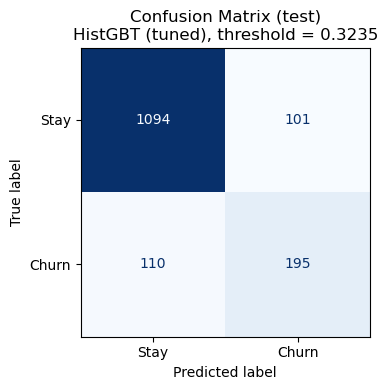

In [110]:
# Confusion matrix at the locked threshold (test set)
# Purpose: turn predicted probabilities into an actionable churn or stay decision,
# then summarise correct and incorrect decisions in a confusion matrix.
# LOCKED_THRESH was chosen earlier on validation only (to avoid test leakage).

# 1) Convert probabilities to hard labels using the locked threshold
pred_locked = (proba_test >= LOCKED_THRESH).astype(int)

# 2) Basic threshold metrics from the test set
tp = int(((y_test == 1) & (pred_locked == 1)).sum())
fp = int(((y_test == 0) & (pred_locked == 1)).sum())
tn = int(((y_test == 0) & (pred_locked == 0)).sum())
fn = int(((y_test == 1) & (pred_locked == 0)).sum())

rec_locked  = round(recall_score(y_test, pred_locked), 4)                         # TP / (TP + FN)
prec_locked = round(precision_score(y_test, pred_locked, zero_division=0), 4)     # TP / (TP + FP)

n_flagged = int(pred_locked.sum())
n_test    = len(y_test)

print(f"Locked threshold = {LOCKED_THRESH}")
print(f"Flagged customers: {n_flagged}/{n_test} ({100*n_flagged/n_test:.1f}%)")
print(f"Confusion counts: TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Recall={rec_locked}  Precision={prec_locked}")

# 3) Plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_locked,
    display_labels=["Stay", "Churn"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"Confusion Matrix (test)\n{FINAL_MODEL_NAME}, threshold = {LOCKED_THRESH}")
fig.tight_layout()
fig.savefig("outputs/5a_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4b PR curve — validation vs test (generalisation check)



The two curves nearly overlap (val PR-AUC 0.7324, test 0.7344), confirming the model's precision–recall trade-off generalises. The locked threshold (red dot) sits in the steep part of the curve where small recall gains cost meaningful precision — consistent with the top-20 % operating point chosen before.

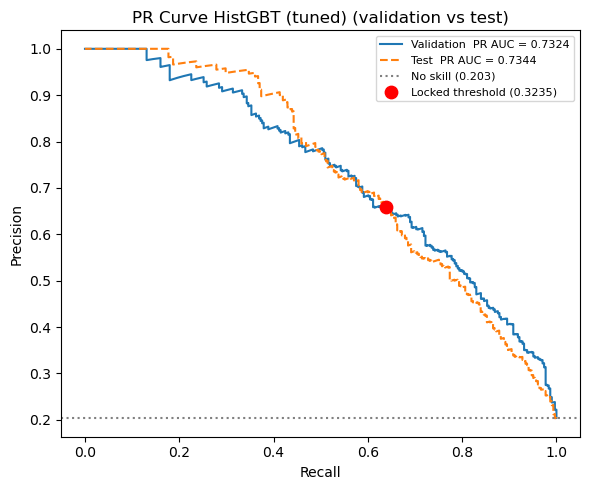

In [113]:
# Build precision recall curves (these sweep over all possible thresholds)
prec_val_curve, rec_val_curve, _   = precision_recall_curve(y_val,  proba_val)
prec_test_curve, rec_test_curve, _ = precision_recall_curve(y_test, proba_test)

# PR AUC is Average Precision, a single number summary of the PR curve
prauc_val  = round(average_precision_score(y_val,  proba_val), 4)
prauc_test = round(average_precision_score(y_test, proba_test), 4)

fig2, ax2 = plt.subplots(figsize=(6, 5))

# Plot both curves on the same axes so we can compare validation vs test
ax2.plot(rec_val_curve,  prec_val_curve,  label=f"Validation  PR AUC = {prauc_val}")
ax2.plot(rec_test_curve, prec_test_curve, label=f"Test  PR AUC = {prauc_test}", linestyle="--")

# No skill reference line equals churn prevalence on the test set
ax2.axhline(y_test.mean(), color="gray", linestyle=":", label=f"No skill ({y_test.mean():.3f})")

# Mark the operating point from the locked threshold used for the confusion matrix
ax2.scatter([rec_locked], [prec_locked], zorder=5, color="red", s=80,
            label=f"Locked threshold ({LOCKED_THRESH})")

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title(f"PR Curve {FINAL_MODEL_NAME} (validation vs test)")
ax2.legend(loc="upper right", fontsize=8)

fig2.tight_layout()
fig2.savefig("outputs/5b_pr_curve.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.4c Calibration and score distribution

**Calibration curve** 
- The reliability curve tracks the diagonal reasonably well at low to mid predicted probabilities, indicating that the model is broadly well calibrated in the range where most customers sit.
- At higher predicted probabilities (roughly above 0.6), the curve lies mostly above the diagonal, which suggests slight underconfidence in the high-risk region: when the model outputs 0.7 to 0.9, the realised churn rate is often even higher.
- There is a small mid-range segment (around 0.5 to 0.6) where the curve dips just below the diagonal, implying mild overconfidence, but the main pattern at the top end is underconfidence rather than overconfidence.


**Score distribution and locked threshold (0.3235)**
- The score distribution provides a consistent picture. Stay probabilities concentrate near zero, while churn probabilities shift right and spread across higher values. The locked threshold of 0.3235 sits in a low-stay-density region with noticeably more churn mass, so it is a sensible cutoff for the confusion matrix view. Some overlap remains, but the separation is clear enough to support the chosen operating point.

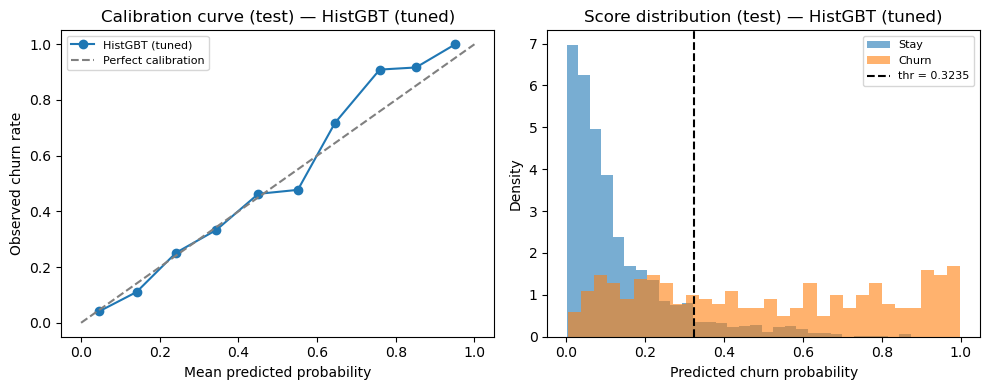

In [115]:
 
fig3, axes3 = plt.subplots(1, 2, figsize=(10, 4))

# Calibration curve: compare mean predicted probability vs actual churn rate in bins
pt, pp = calibration_curve(y_test, proba_test, n_bins=10)
axes3[0].plot(pp, pt, marker="o", label=FINAL_MODEL_NAME, color="tab:blue")
axes3[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes3[0].set_xlabel("Mean predicted probability")
axes3[0].set_ylabel("Observed churn rate")
axes3[0].set_title(f"Calibration curve (test) — {FINAL_MODEL_NAME}")
axes3[0].legend(fontsize=8)

# Score distribution: probability histograms for stay vs churn, with the locked threshold marked
axes3[1].hist(proba_test[y_test == 0], bins=30, alpha=0.6, label="Stay", density=True)
axes3[1].hist(proba_test[y_test == 1], bins=30, alpha=0.6, label="Churn", density=True)
axes3[1].axvline(LOCKED_THRESH, color="black", linestyle="--", label=f"thr = {LOCKED_THRESH}")
axes3[1].set_xlabel("Predicted churn probability")
axes3[1].set_ylabel("Density")
axes3[1].set_title(f"Score distribution (test) — {FINAL_MODEL_NAME}")
axes3[1].legend(fontsize=8)

fig3.tight_layout()
fig3.savefig("outputs/5c_calibration.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.4d Failure-mode slice: Geography

**Germany** shows the strongest ranking quality (**PR AUC = 0.8166**), but the lowest **Recall at top 20 percent = 0.5702**. This is largely a budget effect: Germany’s churn rate is higher (**0.3081**), so a fixed 20 percent outreach cap cannot cover as large a share of churners as it can in lower churn regions. A rough upper bound is **20% / 30.81% ≈ 0.65**, so recall around 0.57 is plausible even with good ranking.

**Spain** has a lower churn rate (**0.1619**) and therefore achieves the highest **Recall at top 20 percent = 0.7193**, since the same 20 percent budget covers a larger fraction of the churner pool. **France** sits between these two patterns.

Overall dispersion is material: the **PR AUC gap across geographies is 0.1579** (max minus min). This suggests geography is a meaningful source of performance variation and should be monitored in deployment. If the bank requires more uniform retention coverage, a practical mitigation would be to allocate the outreach budget by geography rather than using a global 20 percent cutoff.

In [112]:
# Get the Geography label for each test row (same row order as y_test)
geo_vals    = df_model.loc[y_test.index, "Geography"].values
y_test_vals = y_test.values  # numpy array for fast masking

geo_rows = []
for geo in sorted(set(geo_vals)):
    mask = (geo_vals == geo)          # select rows for this country
    y_sl = y_test_vals[mask]          # true labels for this country
    p_sl = proba_test[mask]           # predicted probabilities for this country

    # Skip edge case: if no churners exist in a slice, PR AUC is undefined
    if y_sl.sum() == 0:
        continue

    # Top 20 percent targeting metrics within this country slice
    rec_sl, prec_sl = recall_precision_top(pd.Series(y_sl), p_sl)

    geo_rows.append({
        "Geography":     geo,
        "N":             int(len(y_sl)),
        "Churners":      int(y_sl.sum()),
        "Churn rate":    round(float(y_sl.mean()), 4),
        "PR-AUC":        round(float(average_precision_score(y_sl, p_sl)), 4),
        "Recall@top20%": rec_sl,
    })

geo_df = pd.DataFrame(geo_rows)
print(f"\nFailure mode slice by Geography (test) — {FINAL_MODEL_NAME}")
display(geo_df)

# Simple dispersion summary: how far apart the best and worst PR AUC are
gap = geo_df["PR-AUC"].max() - geo_df["PR-AUC"].min()
print(f"PR AUC gap across geographies (max minus min): {gap:.4f}")


Failure mode slice by Geography (test) — HistGBT (tuned)


,Geography,N,Churners,Churn rate,PR-AUC,Recall@top20%
0,France,778,134,0.1722,0.6587,0.6119
1,Germany,370,114,0.3081,0.8166,0.5702
2,Spain,352,57,0.1619,0.7528,0.7193


PR AUC gap across geographies (max minus min): 0.1579


### 5.5 Agent tooling expectation: explicit agent made mistakes I caught and fixed

I used an agent to speed up drafting and code scaffolding, but I treated every output as provisional and verified it against the assignment rules, runtime behaviour, and methodological discipline. Below are clear agent made mistakes I identified, why they mattered, and exactly how I corrected them.

**1. Test based selection leak (most serious)**
The agent initially selected the final model using **test PR AUC** in Final test evaluation. That would leak information from the test set into model selection and make the reported test performance optimistically biased.
I corrected this by restructuring the workflow so that "Lock All Choices on Validation" section **locks the final model using validation PR AUC only before any test access**, and Final test evaluation becomes **pure reporting** of the already locked choice.

**2. Wrong `calibration_curve` import**
The agent imported `calibration_curve` from `sklearn.metrics`, which is the wrong module, causing an ImportError at runtime.
I fixed the import to `from sklearn.calibration import calibration_curve` and reran the calibration diagnostics successfully.

**3. Metrics alignment gap**
The agent initially evaluated only three metrics in Task 5 and omitted Precision at top 20 percent, which was inconsistent with the success metrics defined earlier.
I added **Precision at top 20 percent** as a fourth metric across all tables so the evaluation matched the operational decision rule and success metric setting in task 1 .

**4. Stale and misleading text outputs**
Some print statements still referred to selecting on the test set and used outdated step numbering from an earlier design.
I replaced them with accurate language, including “ALL CHOICES LOCKED (validation only)” and “OFFICIAL TEST RESULT”, so the notebook narrative matches the actual workflow.



## Task 6. Present the final solution

### 6.1 Final model selection with rationale

The tuned HistGradientBoostingClassifier is selected as the final model, applied under a top-20% ranking rule that contacts the highest-risk fifth of the customer base. HistGBT was shortlisted as the best model in Task 4 because it led on all four validation metrics at default settings when compared with Logistic Regression and Random Forest. It is then tuned in Task 5 (ΔPR-AUC = +0.007), confirming that sklearn's defaults were already near-optimal. The final lock was made on validation PR-AUC (the pre-committed primary criterion) before the test set was accessed. On the held-out test set, HistGBT achieves a PR-AUC of 0.7344. That is comfortably above the no-skill baseline of approximately 0.20, and remarkably close to its validation score (Δ = +0.002), indicating the model has not overfit. At the operational cut-off (top 20% of predicted risk), the model captures 64.3% of actual churners (Recall at top-20% = 0.6426) with a precision of 0.6533, meaning roughly two in three customers flagged for retention are genuine churners. The geography diagnostic shows a cross-country PR-AUC gap of 0.158 (Germany: 0.817; France: 0.659; Spain: 0.753), with Germany's higher base churn rate creating a ceiling effect on recall. This is a pattern to monitor in deployment. 

Overall, HistGBT is selected because it performed best on the validation success metric, especially the primary one (i.e., PR AUC). Also, it maintained that advantage on the held-out test set and delivered strong capacity-constrained targeting performance aligned with the campaign objective.


  

### 6.2 Limitations, risks, and next steps

 

**Data and evaluation limitations.** The model is trained on 10,000 customers from a single bank dataset with 14 features. But none of those data capture temporal or behavioural signals (e.g., transaction trends or recent service interactions). This limits the model’s ability to detect early-warning patterns that evolve over time.  Furthermore, the evaluation relies on a random stratified train/validation/test split rather than a temporal out-of-time hold-out.  However, in a production setting, the joint distribution of features and churn propensity is likely to shift over time. Therefore, the current evaluation design cannot quantify that risk. The geographic scope is also limited to France, Germany, and Spain, so generalisation to other banks, regions, or customer segments requires fresh validation.
 
**Operational risks and next steps.** Two risks warrant monitoring after deployment. First, calibration drift: the model's predicted probabilities may diverge from observed churn rates as the customer population evolves, which would degrade any threshold-based decision rule (though the top-20% ranking is robust to monotonic calibration shifts). Second, subgroup performance differences: the geography slice already shows that Germany's Recall@top-20% (0.5702) is materially lower than Spain's (0.7193), partly due to Germany's higher base churn rate creating a ceiling effect at the 20% budget. If the retention campaign has region-specific costs, separate per-region thresholds may be warranted. Recommended next steps include: (i) periodic recalibration using recent labelled data; (ii) temporal validation once time-stamped churn records become available; (iii) enriching the feature set with behavioural variables (e.g. login frequency, complaint history) to improve recall; and (iv) a cost-sensitive analysis that weights false negatives and false positives by their financial impact, which may shift the optimal operating point away from the fixed 20% rule.


### 6.3 Model card   

| Field | Detail |
|-------|--------|
| **Model** | HistGradientBoostingClassifier (scikit-learn), tuned via RandomizedSearchCV (8 iterations, 3-fold CV on training data, scoring = average precision). |
| **Intended use** | Ranking bank customers by churn risk so that a fixed-capacity retention campaign (budget = top 20% of the customer base) contacts the highest-risk individuals first. |
| **Not intended for** | Individual causal explanations of why a specific customer churns; real-time scoring requiring sub-millisecond latency; generalisation to banks, countries, or product lines outside the training distribution. |
| **Data provenance and constraints** | 10,000 customers from a single bank (Kaggle "Bank Customer Churn" dataset, CC0 licence). Ten features: CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Geography, Gender. No temporal or behavioural features. Class balance: approximately 20% churn. |
| **Evaluation summary (test)** | PR-AUC = 0.7344; ROC-AUC = 0.8737; Recall@top-20% = 0.6426; Precision@top-20% = 0.6533. Validation-to-test PR-AUC shift = +0.002 (stable). All decisions locked on validation; test accessed once for reporting only. |
| **Key caveats and monitoring** | (1) Random split, not temporal — real-world drift is unquantified. (2) Geography gap: Germany Recall@top-20% = 0.5702 vs. Spain = 0.7193 — monitor per-region miss rates. (3) Calibration should be re-assessed periodically if threshold-based rules are adopted. (4) No behavioural features — predictive ceiling likely exists; richer data may improve recall. |